In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Zadania Lista 2

**Wymagania**

- Jupyter'a  należy uruchomić korzystając ze środowiska w kontenerze Docker, w przeciwnym razie przyznane będzie 80% zdobytych punktów. (To wymaganie zostanie z nami do końca kursu, zgodnie z przedstawionymi zasadami.)

#### 1. (5 pkt) Wykonaj podzadania zdefiniowane w punktach a), b) i c) z wykorzystaniem bibliotek `numpy` i `matplotlib`

a) **(2.5 pkt)** Poniżej przedstawiono implementację funkcji `calculate`, w której zrealizowano zbiór operacji na dwóch dwuwymiarowych macierzach $a$ i $b$. Zmień implementację tej funkcji tak, aby pozbyć się wykorzystania pętli - w tym celu wykorzystaj operacje zdefiniowane w bibliotece `numpy`. Zweryfikuj poprawność nowo zdefiowanej funkcji dla dowolnie wybranego zestawu parametrów

```python
def calculate(
    a: np.ndarray, 
    b: np.ndarray,
    threshold: int = 5
) -> float:
'''Implements bunch of operations on matrices.'''
    # Check a and b dimensions
    assert a.shape == b.shape
    # Check whether array is 2D 
    assert len(a.shape) == 2

    rows = a.shape[0]
    cols = a.shape[1]
    b_sum = 0
    out = 0.0
    c = np.zeros(a.shape)

    for row_id in range(rows):
        for col_id in range(cols):
            if a[row_id][col_id] > threshold:
                c[row_id][col_id] = abs(
                    a[row_id][col_id] - b[row_id][col_id]
                )
            else:
                c[row_id][col_id] = 1

            b_sum += b[row_id][col_id]


    row_avgs = []
    for row_id in range(rows):
        row_sum = 0
        for col_id in range(cols):
            row_sum += c[row_id][col_id]

        row_avg = row_sum / cols
        out += (row_avg * 100) / b_sum  

    return out
```


In [7]:
def calculate_old(
    a: np.ndarray, 
    b: np.ndarray,
    threshold: int = 5
) -> float:
    '''Implements bunch of operations on matrices.'''
    # Check a and b dimensions
    assert a.shape == b.shape
    # Check whether array is 2D 
    assert len(a.shape) == 2

    rows = a.shape[0]
    cols = a.shape[1]
    b_sum = 0
    out = 0.0
    c = np.zeros(a.shape)

    for row_id in range(rows):
        for col_id in range(cols):
            if a[row_id][col_id] > threshold:
                c[row_id][col_id] = abs(
                    a[row_id][col_id] - b[row_id][col_id]
                )
            else:
                c[row_id][col_id] = 1

            b_sum += b[row_id][col_id]


    row_avgs = []
    for row_id in range(rows):
        row_sum = 0
        for col_id in range(cols):
            row_sum += c[row_id][col_id]

        row_avg = row_sum / cols
        out += (row_avg * 100) / b_sum  

    return out

In [3]:
def calculate(
    a: np.ndarray,
    b: np.ndarray,
    threshold: int = 5
) -> float:
    '''Implements bunch of operations on matrices.'''
    assert a.shape == b.shape
    assert len(a.shape) == 2

    c = np.where(a > threshold, np.abs(a - b), 1)

    b_sum = b.sum()

    row_avgs = c.mean(axis=1)
    out = float(np.sum(row_avgs * 100 / b_sum))

    return out

In [4]:
a = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
b = np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]])

result = calculate(a, b)
print(result)

result_old = calculate_old(a, b)
print(result_old)
print(result == result_old)

18.51851851851852
18.51851851851852
True


b) **(1 pkt)** Dokonaj porównania czasów wykonania funkcji `calculate` i tej zaimplementowanej w punkcie 1. Wylosuj macierze wejściowe $a$ i $b$ z rozkładu dyskretnego jednostajnego z zakresu 0-10 oraz przyjmij wartość parametru `threshold` na 5. Obliczenia przeprowadź dla następujących wymiarów macierzy:

- 10x10
- 100x100
- 1000x1000
- 10000x10000

**Uwaga**
W celu mierzenia czasu można użyć komendy %timeit
https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit


In [5]:
sizes = [10, 100, 1000, 10000]
rng = np.random.default_rng(42)

times_old = []
times_new = []

for n in sizes:
    a = rng.integers(0, 11, size=(n, n)).astype(float)
    b = rng.integers(0, 11, size=(n, n)).astype(float)
    
    print(f"\n=== {n}x{n} ===")
    
    print("calculate_old:")
    result_old = %timeit -o calculate_old(a, b, threshold=5)
    
    print("calculate:")
    result = %timeit -o calculate(a, b, threshold=5)
    
    times_old.append(result_old)
    times_new.append(result)



=== 10x10 ===
calculate_old:
61.7 μs ± 124 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
calculate:
8.01 μs ± 161 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

=== 100x100 ===
calculate_old:
5.95 ms ± 359 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
calculate:
22.9 μs ± 204 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

=== 1000x1000 ===
calculate_old:
591 ms ± 7.48 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
calculate:
2.53 ms ± 32.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

=== 10000x10000 ===
calculate_old:
1min ± 1.01 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
calculate:
355 ms ± 74.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


c) **(1.5 pkt)** Wykorzystując bibliotekę `matplotlib` narysuj wykres porównujący czas działania obu implementacji dla poszczególnych rozmiarów macierzy. Dobierz odpowiedni typ wykresu, podpisz etykiety osi i uzupełnij tytuł wykresu.

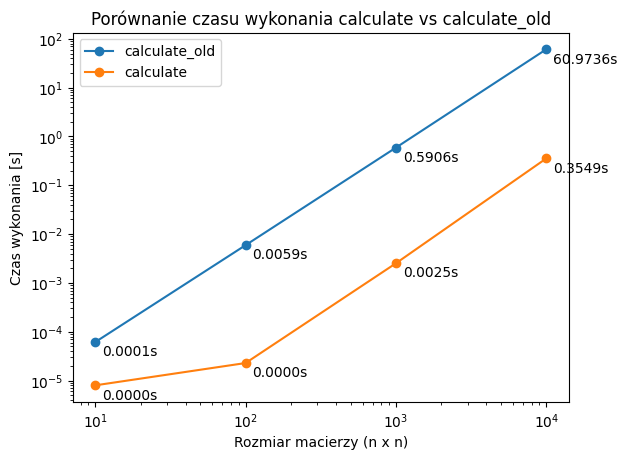

In [6]:
plt.figure()

for i, n in enumerate(sizes):
    t_old = [r.average for r in times_old][i]
    t_new = [r.average for r in times_new][i]
    
    plt.annotate(f"{t_old:.4f}s", (n, t_old), textcoords="offset points", xytext=(5, -10))
    plt.annotate(f"{t_new:.4f}s", (n, t_new), textcoords="offset points", xytext=(5, -10))

plt.plot(sizes, [r.average for r in times_old], label="calculate_old", marker="o")
plt.plot(sizes, [r.average for r in times_new], label="calculate", marker="o")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Rozmiar macierzy (n x n)")
plt.ylabel("Czas wykonania [s]")
plt.title("Porównanie czasu wykonania calculate vs calculate_old")
plt.legend()
plt.show()

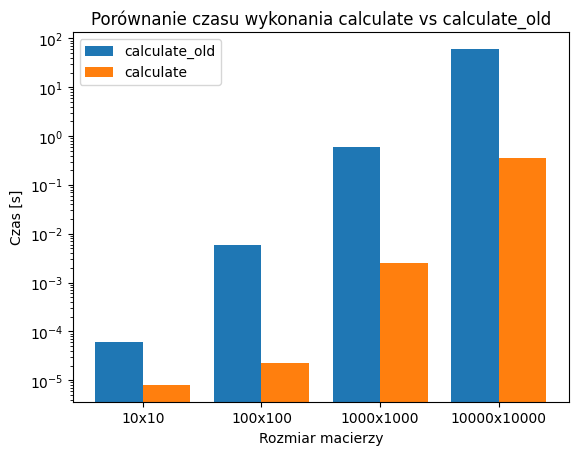

In [7]:
plt.figure()

x = np.arange(len(sizes))
width = 0.4

plt.bar(x - width/2, [r.average for r in times_old], width, label="calculate_old")
plt.bar(x + width/2, [r.average for r in times_new], width, label="calculate")

plt.xticks(x, [f"{n}x{n}" for n in sizes])
plt.yscale("log")
plt.ylabel("Czas [s]")
plt.xlabel("Rozmiar macierzy")
plt.title("Porównanie czasu wykonania calculate vs calculate_old")
plt.legend()

#### 2. (5 pkt) Wykonaj podzadania zdefiniowane w punktach a), b), c) i d) z wykorzystaniem bibliotek `pandas`, `matplotlib`.

a) **(0.25 pkt)** Pobierz zbiór danych [boston house prices](https://lib.stat.cmu.edu/datasets/boston) i wczytaj go do postaci `DataFrame` z biblioteki `pandas`. Dodatkowo wyświetl 20 pierwszych rekordów.

In [8]:
url = "https://lib.stat.cmu.edu/datasets/boston"
raw = pd.read_csv(url, sep=r"\s+", skiprows=22, header=None)

# Every two rows is one record, we need to merge them together
data = np.hstack([raw.values[::2, :], raw.values[1::2, :3]])

columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
           'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

df = pd.DataFrame(data, columns=columns)
print(df.shape)
df.head(20)


(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.10,18.9


In [9]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


b) **(0.75 pkt)** Używając funkcji `apply` utwórz kolumnę 'HIGH_TAX', która sprawdza czy dla danego rekordu stawka podatkowa (kolumna 'TAX')  jest większa od mediany stawki podatkowej wszystkich rekordów



In [10]:
median_tax = df['TAX'].median()
df['HIGH_TAX'] = df['TAX'].apply(lambda x: x > median_tax)

df['HIGH_TAX'].value_counts()

HIGH_TAX
False    256
True     250
Name: count, dtype: int64

c) **(1.5 pkt)** Pogrupuj rekordy wg. kolumny 'HIGH_TAX' i wybierz 4 cechy ze zbioru danych w których najbardziej widać różnicę dla grup 'HIGH_TAX'



In [11]:
grouped = df.groupby('HIGH_TAX').mean()
grouped

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
HIGH_TAX,,,,,,,,,,,,,,
False,0.249547,15.966797,6.826953,0.078125,0.486659,6.476523,56.979687,4.740493,4.367188,273.519531,17.853125,387.590586,9.64418,25.980078
True,7.058236,6.650000,15.550040,0.060000,0.624364,6.088140,80.448400,2.826902,14.856000,546.188000,19.072400,325.015480,15.73416,19.002800


In [12]:
diff = (grouped.loc[True] - grouped.loc[False]).abs()
diff.sort_values(ascending=False).head(4)


TAX    272.668469
B       62.575106
AGE     23.468712
RAD     10.488812
dtype: float64

d) **(2.5 pkt)** Dla wybranych cech w punkcie `c)` porównaj wartości tych cech na wykresach. Dobierz odpowiedni typ wykresu (słupkowy, kołowy, liniowy, histogram, ...). Wybór typu musi być zasadny. Wykresy mają być umiejscowione w jednym wykresie z subplotem składającym się z 2 kolumn i 2 rzędów. Wykresy powinny posiadać etykiety osi X i Y oraz legendę.
Uwaga: wykresy z jedynie dwoma punktami danych np. średnie wartości dla dwóch grup nie będą akceptowane. Do takich danych służą tabele.


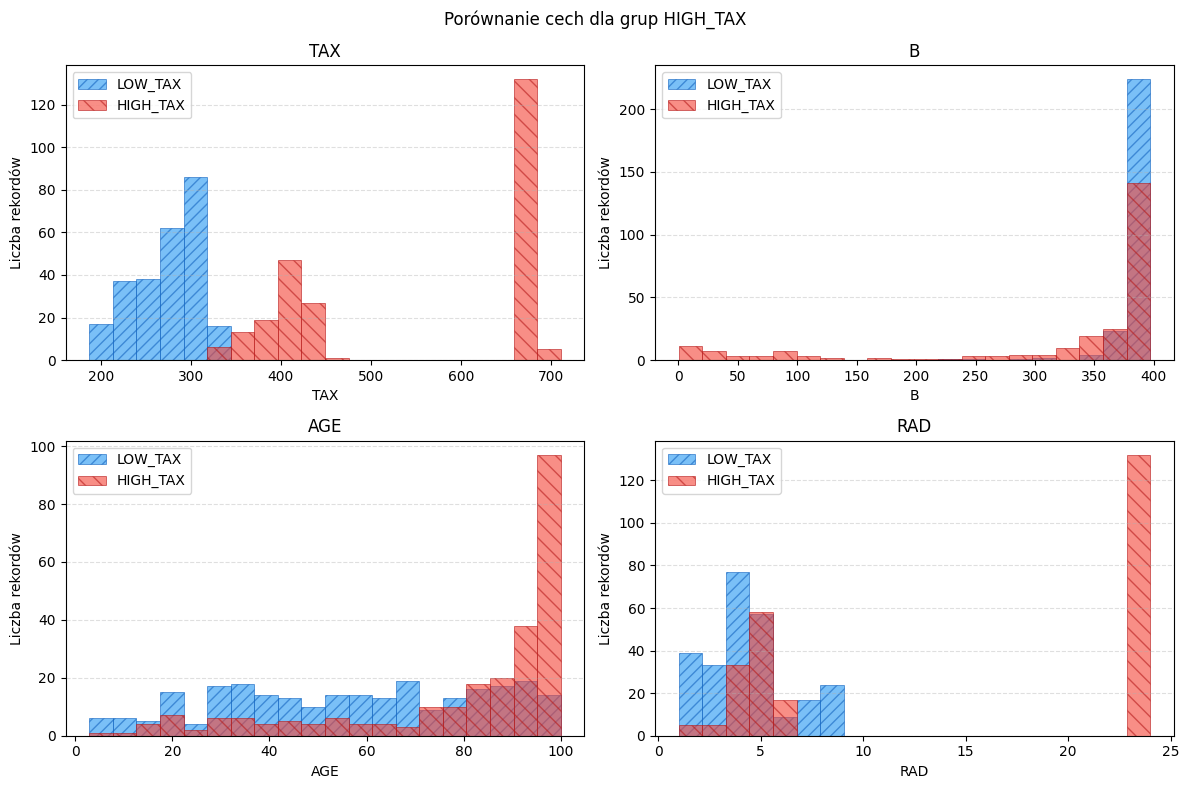

In [14]:
top4 = diff.sort_values(ascending=False).head(4).index.to_list()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

low  = df[df['HIGH_TAX'] == False]
high = df[df['HIGH_TAX'] == True]

for i, col in enumerate(top4):
    ax = axes[i]

    min_val = min(low[col].min(), high[col].min())
    max_val = max(low[col].max(), high[col].max())
    bins = np.linspace(min_val, max_val, 21)

    ax.hist(low[col],  bins=bins, alpha=0.6, color='#2196F3', label='LOW_TAX',  edgecolor='#1565C0', linewidth=0.7, hatch='///')
    ax.hist(high[col], bins=bins, alpha=0.6, color='#F44336', label='HIGH_TAX', edgecolor='#B71C1C', linewidth=0.7, hatch='\\\\')
    ax.set_xlabel(col)
    ax.set_ylabel('Liczba rekordów')
    ax.set_title(col)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
plt.suptitle('Porównanie cech dla grup HIGH_TAX')
plt.tight_layout()
plt.show()

#### [OPCJONALNE] 3. (1 pkt) Zapoznaj się z biblioteką [polars](https://docs.pola.rs/) i wykonaj polecenia 2 a) b) c) korzystając z tej biblioteki 

In [14]:
import polars as pl

# Using pandas for initial loading as Polars does not support regex separators (\s+), converted to Polars for cleaner syntax
df_pl = pl.from_pandas(df)
df_pl.head(20)


CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,HIGH_TAX
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,296.0,15.3,396.9,4.98,24.0,false
0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.9,9.14,21.6,false
0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7,false
0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4,false
0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.9,5.33,36.2,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.62739,0.0,8.14,0.0,0.538,5.834,56.5,4.4986,4.0,307.0,21.0,395.62,8.47,19.9,false
1.05393,0.0,8.14,0.0,0.538,5.935,29.3,4.4986,4.0,307.0,21.0,386.85,6.58,23.1,false
0.7842,0.0,8.14,0.0,0.538,5.99,81.7,4.2579,4.0,307.0,21.0,386.75,14.67,17.5,false


In [15]:
median_tax = df_pl['TAX'].median()
df_pl = df_pl.with_columns(
    (pl.col('TAX') > median_tax).alias('HIGH_TAX')
)
df_pl['HIGH_TAX'].value_counts()

HIGH_TAX,count
bool,u32
false,256
true,250


In [16]:
grouped_pl = df_pl.group_by('HIGH_TAX').mean().sort('HIGH_TAX')
grouped_pl

HIGH_TAX,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
false,0.249547,15.966797,6.826953,0.078125,0.486659,6.476523,56.979687,4.740493,4.3671875,273.519531,17.853125,387.590586,9.64418,25.980078
true,7.058236,6.65,15.55004,0.06,0.624364,6.08814,80.4484,2.826902,14.856,546.188,19.0724,325.01548,15.73416,19.0028


In [17]:
true_vals  = grouped_pl.filter(pl.col('HIGH_TAX') == True).drop('HIGH_TAX')
false_vals = grouped_pl.filter(pl.col('HIGH_TAX') == False).drop('HIGH_TAX')

diff_pl = (true_vals - false_vals).with_columns(pl.all().abs())

diff_pl.unpivot().sort('value', descending=True).head(4)

variable,value
str,f64
"""TAX""",272.668469
"""B""",62.575106
"""AGE""",23.468712
"""RAD""",10.488812


#### [OPCJONALNE] 4. (1 pkt) Zapoznaj się z biblioteką [seaborn](https://seaborn.pydata.org/index.html) i zmień wykresy z punktu 2 d) na używające tej biblioteki

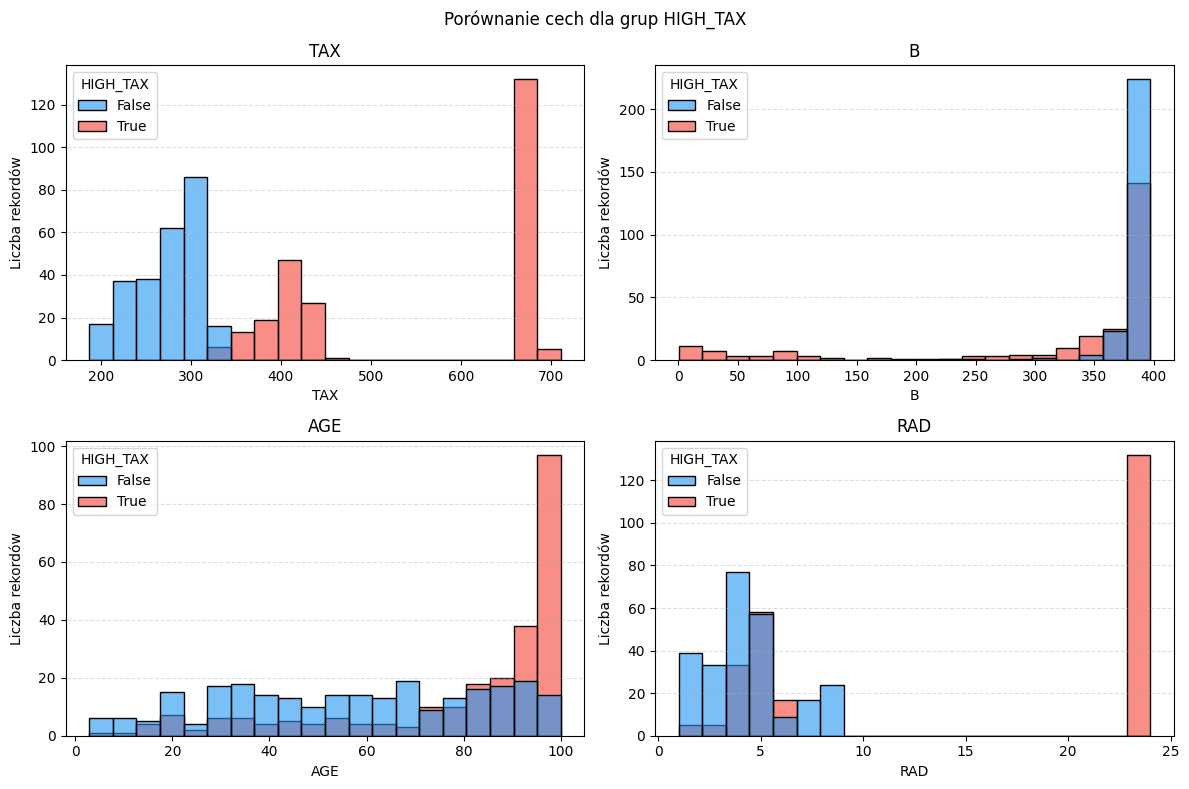

In [18]:
import seaborn as sns

top4 = diff.sort_values(ascending=False).head(4).index.to_list()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(top4):
    ax = axes[i]

    sns.histplot(
        data=df,
        x=col,
        hue='HIGH_TAX',
        ax=ax,
        bins=20,
        alpha=0.6,
        multiple='layer',
        palette={False: '#2196F3', True: '#F44336'}
    )

    ax.set_xlabel(col)
    ax.set_ylabel('Liczba rekordów')
    ax.set_title(col)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Porównanie cech dla grup HIGH_TAX')
plt.tight_layout()
plt.show()